2025-02-27 12:16:49.611162: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-27 12:16:49.626929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740658609.637662  652576 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740658609.641305  652576 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-27 12:16:49.652416: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

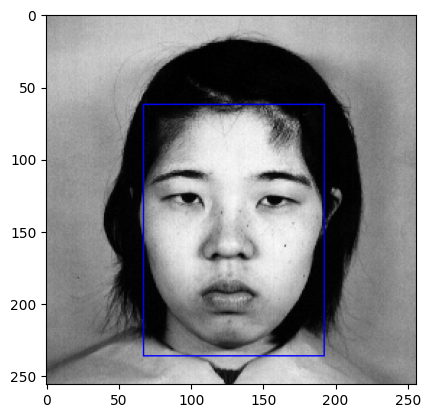

In [1]:
from mtcnn.mtcnn import MTCNN
import matplotlib.pyplot as plt 
import cv2 

detector = MTCNN()
test = []
img = cv2.imread('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/test/0/KM.AN2.18.png')
# test.append(img)
# img = cv2.imread('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/test/0/MK.AN3.127.png')
# test.append(img)

results = detector.detect_faces(img)
x,y,w,h = results[0]['box']
img = cv2.rectangle(img, (x,y), (x+w, y+h), (0,0,255), 1)
plt.imshow(img)
my_face = img[y:y+h, x:x+w]



In [2]:
import os
import numpy as np
from PIL import Image
# Reference for using MTCNN to extract face
# Resource video: https://www.youtube.com/watch?v=bG2tNYs7gw8
# Resource for code: https://colab.research.google.com/drive/1TjgM1Uy9TIUk091cAmLEnqk9XqUtoqUF#scrollTo=9U_uHILx0Bd8
class FACELOADING:
    def __init__(self, directory):
        self.directory = directory
        self.target_size = (224,224)
        self.X = []
        self.Y = []
        self.corr = 0
        self.wro = 0
        self.detector = MTCNN()
    

    def extract_face(self, filename):
        img = cv2.imread(filename)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        face = self.detector.detect_faces(img)
        # Alteration to code to set face as whole image, even if no face is detected by MTCNN.
        # Aids in handling inconsistencies with MTCNN.
        if face:
            x,y,w,h = face[0]['box']
            x,y = abs(x), abs(y)
            face = img[y:y+h, x:x+w]
        else: 
            face = img
        
        face_arr = cv2.resize(face, self.target_size)
        return face_arr

    def load_faces(self, dir):
        FACES = []
        success_count = 0
        fail_count = 0

        for im_name in os.listdir(dir):
            try:
                path = os.path.join(dir, im_name)
                single_face = self.extract_face(path)

                if single_face is not None:
                    FACES.append(single_face)
                    success_count += 1
                else:
                    print(f"Skipping image (no face detected): {im_name}")
                    fail_count += 1  
            except Exception as e:
                print(f"Error processing image {im_name}: {e}")
                fail_count += 1 

        print(f"Successfully processed {success_count} images.")
        print(f"Failed to process {fail_count} images.")
        self.corr +=success_count
        self.wro +=fail_count
        return FACES


    def load_classes(self):
        for sub_dir in os.listdir(self.directory):
            print(sub_dir)
            path = self.directory +'/'+ sub_dir+'/'
            FACES = self.load_faces(path)
            labels = [sub_dir for _ in range(len(FACES))]
            print(f"Loaded successfully: {len(labels)}")
            self.X.extend(FACES)
            self.Y.extend(labels)
        
        return np.asarray(self.X), np.asarray(self.Y)


    def plot_images(self):
        plt.figure(figsize=(18,16))
        for num,image in enumerate(self.X):
            ncols = 32
            nrows = len(self.Y)//ncols + 1
            plt.subplot(nrows,ncols,num+1)
            plt.title(self.Y[num+1])
            plt.imshow(image)
            plt.axis('off')

In [3]:
from PIL import Image
# Make new directories for the new dataset
os.chdir('/user/HS401/ob00564/Documents/COM3001/testing/New')
print(os.getcwd())
def createDir(directory_name):
    try:
        os.mkdir(directory_name)
        print(f"Directory '{directory_name}' created successfully.")
    except FileExistsError:
        print(f"Directory '{directory_name}' already exists.")
    except PermissionError:
        print(f"Permission denied: Unable to create '{directory_name}'.")
    except Exception as e:
        print(f"An error occurred: {e}")

def createSubDir(directory_name):
    for x in range(7):
        newDir = directory_name + "/" + str(x)
        createDir(newDir)

createDir('train')
createDir('validation')
createDir('test')

createSubDir("train")
createSubDir("validation")
createSubDir("test")


/user/HS401/ob00564/Documents/COM3001/testing/New
Directory 'train' created successfully.
Directory 'validation' created successfully.
Directory 'test' created successfully.
Directory 'train/0' created successfully.
Directory 'train/1' created successfully.
Directory 'train/2' created successfully.
Directory 'train/3' created successfully.
Directory 'train/4' created successfully.
Directory 'train/5' created successfully.
Directory 'train/6' created successfully.
Directory 'validation/0' created successfully.
Directory 'validation/1' created successfully.
Directory 'validation/2' created successfully.
Directory 'validation/3' created successfully.
Directory 'validation/4' created successfully.
Directory 'validation/5' created successfully.
Directory 'validation/6' created successfully.
Directory 'test/0' created successfully.
Directory 'test/1' created successfully.
Directory 'test/2' created successfully.
Directory 'test/3' created successfully.
Directory 'test/4' created successfully

In [4]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/testing/New')

def addImagesToSet(dataset_name, faceloading):
    for item in range(len(faceloading.X)):
        os.chdir('/user/HS401/ob00564/Documents/COM3001/testing/New')
        label = faceloading.Y[item]
        img = faceloading.X[item]
        # Resouce: https://stackoverflow.com/questions/55319949/pil-typeerror-cannot-handle-this-data-type
        data = Image.fromarray((img).astype(np.uint8))
        dirString = dataset_name + "/" + str(label)
        os.chdir(dirString)
        data.save(f'{label} Index {item}.png')
# Test set
test_faceloading = FACELOADING("/user/HS401/ob00564/Documents/COM3001/testing/DATASET/test")
test_faceloading.load_classes()
addImagesToSet(dataset_name='test', faceloading=test_faceloading)



6
Successfully processed 105 images.
Failed to process 0 images.
Loaded successfully: 105
2


2025-02-27 12:17:13.674632: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,48,48,3] vs. [1,1,1,32]


Successfully processed 48 images.
Failed to process 0 images.
Loaded successfully: 48
3


2025-02-27 12:17:24.231290: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,48,48,3] vs. [1,1,1,32]


Successfully processed 52 images.
Failed to process 0 images.
Loaded successfully: 52
5
Successfully processed 54 images.
Failed to process 0 images.
Loaded successfully: 54
0
Successfully processed 50 images.
Failed to process 0 images.
Loaded successfully: 50
4
Successfully processed 48 images.
Failed to process 0 images.
Loaded successfully: 48
1
Successfully processed 51 images.
Failed to process 0 images.
Loaded successfully: 51


In [5]:
# Val set
val_faceloading = FACELOADING("/user/HS401/ob00564/Documents/COM3001/testing/DATASET/validation")
val_faceloading.load_classes()
addImagesToSet(dataset_name='validation', faceloading=val_faceloading)
# Train set
train_faceloading = FACELOADING("/user/HS401/ob00564/Documents/COM3001/testing/DATASET/train")
train_faceloading.load_classes()
addImagesToSet(dataset_name='train', faceloading=train_faceloading)

6


2025-02-27 12:18:32.745402: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,24,24,3] vs. [1,1,1,28]


Successfully processed 104 images.
Failed to process 0 images.
Loaded successfully: 104
2
Successfully processed 47 images.
Failed to process 0 images.
Loaded successfully: 47
3
Successfully processed 52 images.
Failed to process 0 images.
Loaded successfully: 52
5
Successfully processed 53 images.
Failed to process 0 images.
Loaded successfully: 53
0
Successfully processed 49 images.
Failed to process 0 images.
Loaded successfully: 49
4
Successfully processed 48 images.
Failed to process 0 images.
Loaded successfully: 48
1
Successfully processed 51 images.
Failed to process 0 images.
Loaded successfully: 51
6


2025-02-27 12:21:23.888214: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,48,48,3] vs. [1,1,1,32]


Successfully processed 834 images.
Failed to process 0 images.
Loaded successfully: 834
2
Successfully processed 382 images.
Failed to process 0 images.
Loaded successfully: 382
3
Successfully processed 416 images.
Failed to process 0 images.
Loaded successfully: 416
5
Successfully processed 425 images.
Failed to process 0 images.
Loaded successfully: 425
0
Successfully processed 396 images.
Failed to process 0 images.
Loaded successfully: 396
4
Successfully processed 382 images.
Failed to process 0 images.
Loaded successfully: 382
1
Successfully processed 406 images.
Failed to process 0 images.
Loaded successfully: 406


In [7]:
import os
print(os.getcwd())
os.chdir('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/train')

def printTotals():
    classDict = {'0':0,
            '1':0,
            '2':0,
            '3':0,
            '4':0,
            '5':0,
            '6':0,
            }
    total = 0
    for folder_name in os.listdir('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/train'):
        folder_path = os.path.join('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/train', folder_name)
        allImages = os.listdir(folder_path)
        classDict[folder_name] = len(allImages)
        total += len(allImages)
    return classDict, total
x, y = printTotals()
print(x)
print(y)

def printTotals():
    classDict = {'0':0,
            '1':0,
            '2':0,
            '3':0,
            '4':0,
            '5':0,
            '6':0,
            }
    total = 0
    for folder_name in os.listdir('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/validation'):
        folder_path = os.path.join('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/validation', folder_name)
        allImages = os.listdir(folder_path)
        classDict[folder_name] = len(allImages)
        total += len(allImages)
    return classDict, total
x, y = printTotals()
print(x)
print(y)

def printTotals():
    classDict = {'0':0,
            '1':0,
            '2':0,
            '3':0,
            '4':0,
            '5':0,
            '6':0,
            }
    total = 0
    for folder_name in os.listdir('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/test'):
        folder_path = os.path.join('/user/HS401/ob00564/Documents/COM3001/testing/DATASET/test', folder_name)
        allImages = os.listdir(folder_path)
        classDict[folder_name] = len(allImages)
        total += len(allImages)
    return classDict, total
x, y = printTotals()
print(x)
print(y)
# {'0': 351, '1': 361, '2': 336, '3': 371, '4': 337, '5': 380, '6': 789}
# {'0': 49, '1': 51, '2': 47, '3': 52, '4': 48, '5': 53, '6': 104}
# {'0': 95, '1': 96, '2': 94, '3': 97, '4': 93, '5': 99, '6': 150}


/user/HS401/ob00564/Documents/COM3001/testing/DATASET/train
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 49, '1': 51, '2': 47, '3': 52, '4': 48, '5': 53, '6': 104}
404
{'0': 50, '1': 51, '2': 48, '3': 52, '4': 48, '5': 54, '6': 105}
408
